In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import os
os.chdir("..")
os.getcwd()

'/home/akshey/Desktop/PhD/Code_repositories/bundlenet_results'

## Behaviour evaluation plots

/tmp/ipykernel_1916266/2125274715.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algorithms, rotation=90, fontsize=11)


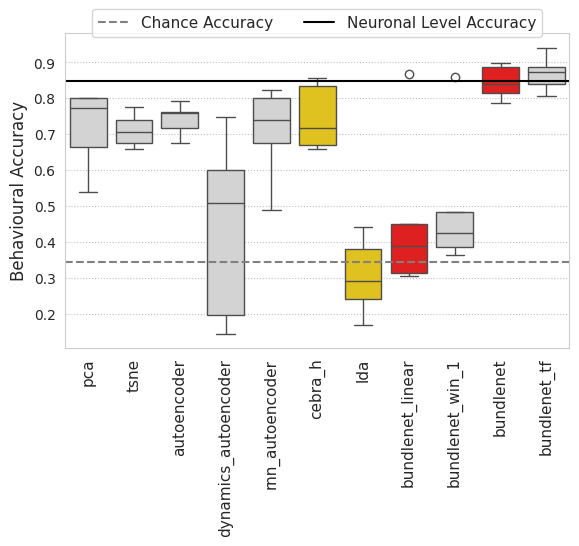

In [6]:
### POOLING WORMS
algorithms = [
    'pca',
    'tsne',
    'autoencoder', 
    'dynamics_autoencoder',
    'rnn_autoencoder',
    'cebra_h',
    'lda', 
    'bundlenet_linear',
    'bundlenet_win_1',
    'bundlenet',
    'bundlenet_tf',

]
acc_array = []
for algorithm in algorithms:
    worm_manifold_acc = []
    worm_chance_acc = []
    worm_neuronal_acc = []
    for worm_num in range(0,5):
        manifold_acc = np.loadtxt(f'data/generated/quantitative_evaluation/evaluation_metrics/c_elegans/acc_list_{algorithm}_worm_{worm_num}')
        neuronal_acc = np.loadtxt(f'data/generated/quantitative_evaluation/evaluation_metrics/c_elegans/acc_list_X_worm_{worm_num}').mean()
        chance_acc = np.loadtxt(f'data/generated/quantitative_evaluation/evaluation_metrics/c_elegans/acc_list_chance_worm_{worm_num}').mean()
        worm_manifold_acc.append(manifold_acc.mean())
        worm_chance_acc.append(chance_acc)
        worm_neuronal_acc.append(neuronal_acc)
        
    acc_array.append(worm_manifold_acc)
    
acc_array = np.array(acc_array)
worm_chance_acc = np.array(worm_chance_acc)
worm_neuronal_acc = np.array(worm_neuronal_acc)

highlight_algorithms = ['bundlenet_linear', 'bundlenet']
supervised_algorithms = ['lda', 'cebra_h']
custom_palette = [
    'red' if algo in highlight_algorithms else (
        'gold' if algo in supervised_algorithms else 'lightgray'
    )
    for algo in algorithms
]
sns.set_style("whitegrid")
color_palette = sns.color_palette("Set3")
plt.figure(figsize=(7, 5))
ax = sns.boxplot(data=acc_array.T, linewidth=1, palette=custom_palette)
ax.set_xticklabels(algorithms, rotation=90, fontsize=11)
ax.set_ylabel("Behavioural Accuracy", fontsize=12)
ax.axhline(worm_chance_acc.mean(), linestyle='--', label='Chance Accuracy', color='gray')
ax.axhline(worm_neuronal_acc.mean(), linestyle='-', label='Neuronal Level Accuracy', color='black')
ax.grid(axis='y', linestyle=':', color='gray', alpha=0.5)
#ax.set_ylim(0,1)
plt.subplots_adjust(bottom=0.25, left=0.18)
ax.legend(fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=2)
#plt.savefig('Figures/behavioural_performance.pdf', bbox_inches='tight', transparent=True)
plt.show()

In [7]:
acc_array.T.shape

(5, 11)

/tmp/ipykernel_1432921/2399625607.py:33: UserWarning: The palette list has more values (12) than needed (6), which may not be intended.
  ax = sns.boxplot(data=acc_array.T[:6], linewidth=1, palette=color_palette)
/tmp/ipykernel_1432921/2399625607.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algorithms, rotation=90, fontsize=11)


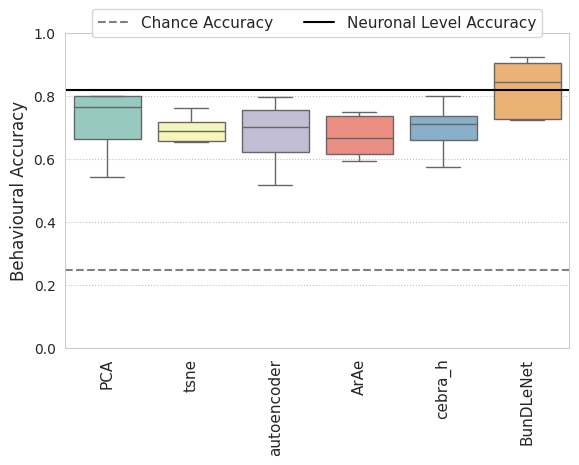

In [97]:
### POOLING WORMS
algorithms = [
    'PCA',
    'tsne',
    'autoencoder',
    'ArAe' ,
    'cebra_h',
    'BunDLeNet' ,
]
acc_array = []
for algorithm in algorithms:
    worm_manifold_acc = []
    worm_chance_acc = []
    worm_neuronal_acc = []
    
    for worm_num in range(5):
        manifold_acc = np.loadtxt(f'data/generated/quantitative_evaluation/evaluation_metrics/c_elegans/old_acc_list_{algorithm}_worm_{worm_num}')
        #neuronal_acc = np.loadtxt(f'data/generated/quantitative_evaluation/evaluation_metrics/c_elegans/acc_list_X_worm_{worm_num}').max()
        #chance_acc = np.loadtxt(f'data/generated/quantitative_evaluation/evaluation_metrics/c_elegans/acc_list_chance_worm_{worm_num}').mean()
        worm_manifold_acc.append(manifold_acc.mean())
        worm_chance_acc.append(chance_acc)
        worm_neuronal_acc.append(neuronal_acc)
        
    acc_array.append(worm_manifold_acc)
    
acc_array = np.array(acc_array)
worm_chance_acc = np.array(worm_chance_acc)
worm_neuronal_acc = np.array(worm_neuronal_acc)

sns.set_style("whitegrid")
color_palette = sns.color_palette("Set3")
plt.figure(figsize=(7, 5))
ax = sns.boxplot(data=acc_array.T[:6], linewidth=1, palette=color_palette)
ax.set_xticklabels(algorithms, rotation=90, fontsize=11)
ax.set_ylabel("Behavioural Accuracy", fontsize=12)
ax.axhline(worm_chance_acc.mean(), linestyle='--', label='Chance Accuracy', color='gray')
ax.axhline(worm_neuronal_acc.mean(), linestyle='-', label='Neuronal Level Accuracy', color='black')
ax.grid(axis='y', linestyle=':', color='gray', alpha=0.5)
ax.set_ylim(0,1)
plt.subplots_adjust(bottom=0.25, left=0.18)
ax.legend(fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=2)
#plt.savefig('Figures/behavioural_performance.pdf', bbox_inches='tight', transparent=True)
plt.show()

In [13]:
'''
plt.figure(figsize=(5,4))
ax = sns.violinplot(data=acc_array.T[:,:])
ax.set_xticklabels(algorithms, rotation=90)
ax.set(ylabel = "Decoding accuracy", title ='Behavioural performance of macrovariable')
ax.axhline(worm_chance_acc.mean(), linestyle='--',label='Chance accuracy') ### Chance accuracy (see Evaluation .ipynb)
ax.axhline(worm_neuronal_acc.mean(), linestyle='-',label='Neuronal level accuracy', color='red') ### Chance accuracy (see Evaluation .ipynb)
ax.legend()'''

'\nplt.figure(figsize=(5,4))\nax = sns.violinplot(data=acc_array.T[:,:])\nax.set_xticklabels(algorithms, rotation=90)\nax.set(ylabel = "Decoding accuracy", title =\'Behavioural performance of macrovariable\')\nax.axhline(worm_chance_acc.mean(), linestyle=\'--\',label=\'Chance accuracy\') ### Chance accuracy (see Evaluation .ipynb)\nax.axhline(worm_neuronal_acc.mean(), linestyle=\'-\',label=\'Neuronal level accuracy\', color=\'red\') ### Chance accuracy (see Evaluation .ipynb)\nax.legend()'

/tmp/ipykernel_1916266/4029012732.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algorithms, rotation=90)
/tmp/ipykernel_1916266/4029012732.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algorithms, rotation=90)
/tmp/ipykernel_1916266/4029012732.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algorithms, rotation=90)
/tmp/ipykernel_1916266/4029012732.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algorithms, rotation=90)
/tmp/ipykernel_1916266/4029012732.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_tick

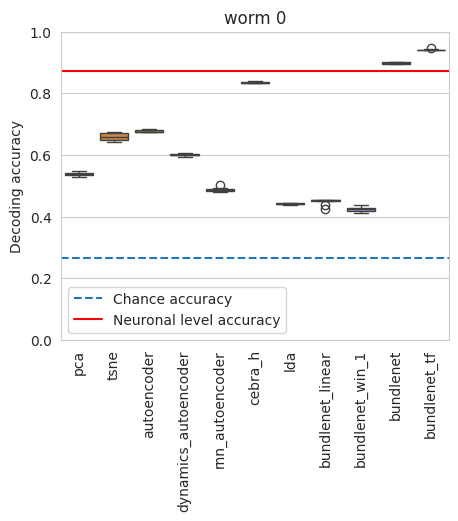

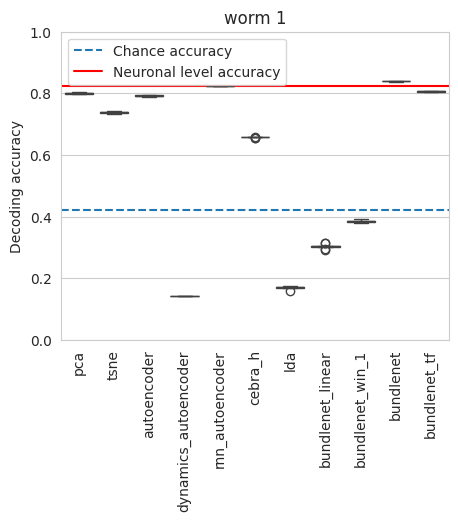

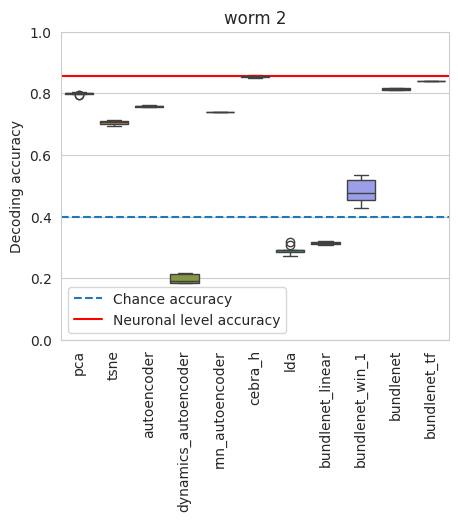

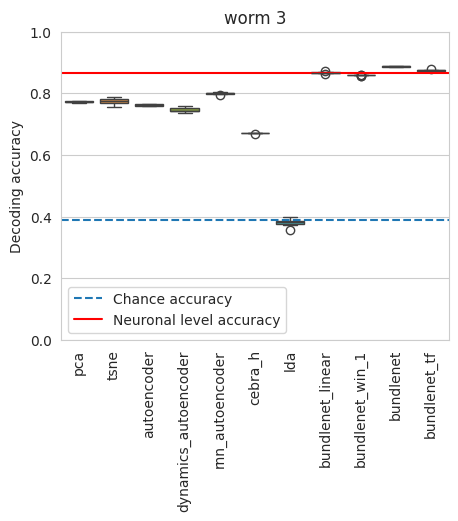

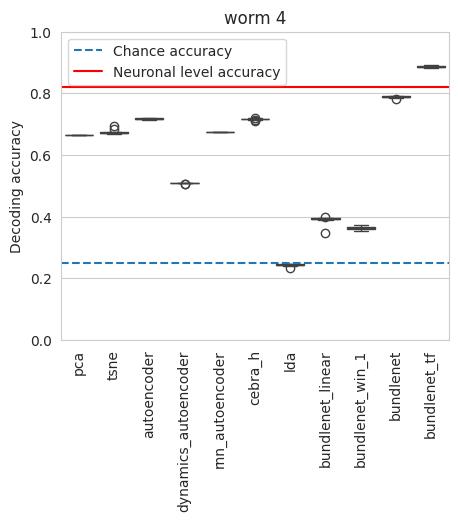

In [8]:
 # Evaluations for each worm individually
for worm_num in range(5):
    
    acc_array = []
    for algorithm in algorithms:
        acc_array.append(np.loadtxt(f'data/generated/quantitative_evaluation/evaluation_metrics/c_elegans/acc_list_{algorithm}_worm_{worm_num}'))
    acc_array = np.array(acc_array)
    ### Neuronal level accuracy (X)
    neuronal_acc = np.loadtxt(f'data/generated/quantitative_evaluation/evaluation_metrics/c_elegans/acc_list_X_worm_{worm_num}').mean()
    chance_acc = np.loadtxt(f'data/generated/quantitative_evaluation/evaluation_metrics/c_elegans/acc_list_chance_worm_{worm_num}').mean()
        


    plt.figure(figsize=(5,4))
    ax = sns.boxplot(data=acc_array.T)
    ax.set_xticklabels(algorithms, rotation=90)
    ax.set_ylim(0,1)
    ax.set(ylabel = "Decoding accuracy", title ='Behavioural performance of macrovariable')
    ax.axhline(chance_acc, linestyle='--',label='Chance accuracy') ### Chance accuracy (see Evaluation .ipynb)
    ax.axhline(neuronal_acc, linestyle='-',label='Neuronal level accuracy', color='red') ### Chance accuracy (see Evaluation .ipynb)
    ax.set_title(f'worm {worm_num}')
    ax.legend()
    #plt.savefig('behavioural_performance.pdf', transparent=True)


## Dynamics evaluation plots

/tmp/ipykernel_1916266/3932631432.py:24: RuntimeWarning: divide by zero encountered in divide
  dyn_pred = 1 - mse_list[:,1] / mse_list[:,3]
/tmp/ipykernel_1916266/3932631432.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(algorithms, rotation=90, fontsize=10)


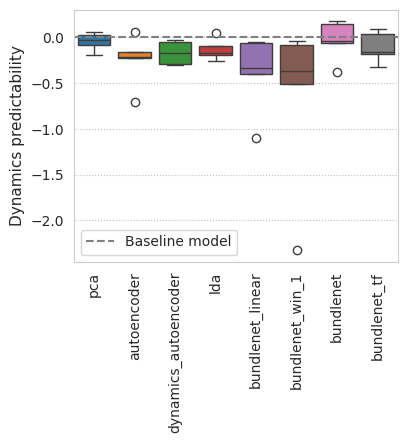

In [9]:
from sklearn.metrics import mean_squared_error as mse

### POOLING WORMS
algorithms = [
    'pca',
    #'tsne',
    'autoencoder', 
    'dynamics_autoencoder',
    #'rnn_autoencoder',
    #'cebra_h',
    'lda', 
    'bundlenet_linear',
    'bundlenet_win_1',
    'bundlenet',
    'bundlenet_tf',

]
dp_array = []
for algorithm in algorithms:
    worm_i_dp = []
    for worm_num in range(5):
        mse_list = np.loadtxt(f'data/generated/quantitative_evaluation/evaluation_metrics/c_elegans/mse_list_{algorithm}_worm_{worm_num}')
        r2_list = np.loadtxt(f'data/generated/quantitative_evaluation/evaluation_metrics/c_elegans/r2_list_{algorithm}_worm_{worm_num}')
        dyn_pred = 1 - mse_list[:,1] / mse_list[:,3]
        worm_i_dp.append(dyn_pred.mean())
    dp_array.append(worm_i_dp)
    
dp_array = np.array(dp_array)


plt.figure(figsize=(4.5, 4))
ax = sns.boxplot(data=dp_array.T, linewidth=1)
ax.set_xticklabels(algorithms, rotation=90, fontsize=10)
ax.yaxis.set_label_text("Dynamics predictability", fontsize=11)
ax.axhline(0.0, linestyle='--',label='Baseline model', color='gray') ### Baseline goodness of fit (by definition)
plt.grid(axis='y', linestyle=':', color='gray', alpha=0.5)
# Adjust the bottom margin
plt.subplots_adjust(bottom=0.25, left=0.18)  # You can modify this value as needed
ax.legend()

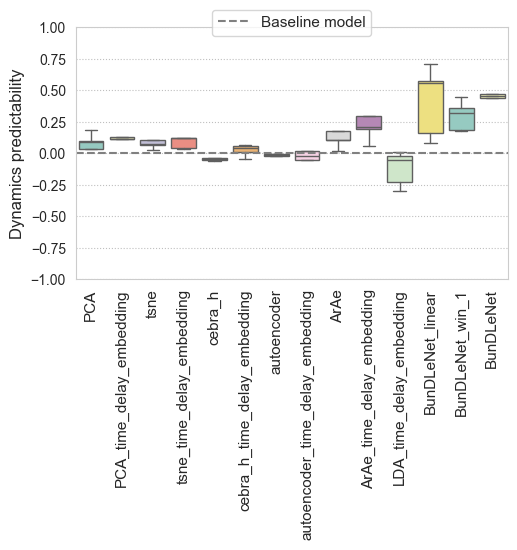

In [20]:
sns.set_style("whitegrid")
color_palette = sns.color_palette("Set3")
plt.figure(figsize=(6, 4))
ax = sns.boxplot(data=dp_array.T[:6], linewidth=1, palette=color_palette, fliersize=0)
ax.set_xticklabels(algorithms, rotation=90, fontsize=11)
ax.yaxis.set_label_text("Dynamics predictability", fontsize=12)

ax.axhline(0.0, linestyle='--',label='Baseline model', color='gray') ### Baseline goodness of fit (by definition)
ax.grid(axis='y', linestyle=':', color='gray', alpha=0.5)
ax.set_ylim(-1,1)
plt.subplots_adjust(bottom=0.25, left=0.18)
ax.legend(fontsize=11, loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=2)
plt.savefig('Figures/dynamical_performance.pdf', bbox_inches='tight', transparent=True)
plt.show()